# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Dataset yang Digunakan:**
Dataset yang dipilih adalah **Breast Cancer Wisconsin (Diagnostic)** dari pustaka bawaan `scikit-learn` (bersumber dari UCI ML Repository). 

**Alasan Pemilihan:**
- Sederhana dan seluruh fiturnya berbentuk numerik sehingga proses *preprocessing* lebih efisien.
- Ukurannya kecil-menengah (569 sampel, 30 fitur) sehingga *training* sangat cepat dan tidak membutuhkan GPU.
- Sangat ideal untuk klasifikasi biner dan sangat mudah mendapatkan nilai evaluasi (akurasi, precision, recall) di atas 95% menggunakan algoritma konvensional.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

# Mengabaikan pesan warning agar output notebook tetap bersih
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset dari scikit-learn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Menambahkan kolom target
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Menampilkan 5 baris pertama untuk inspeksi awal
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Informasi Struktur Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

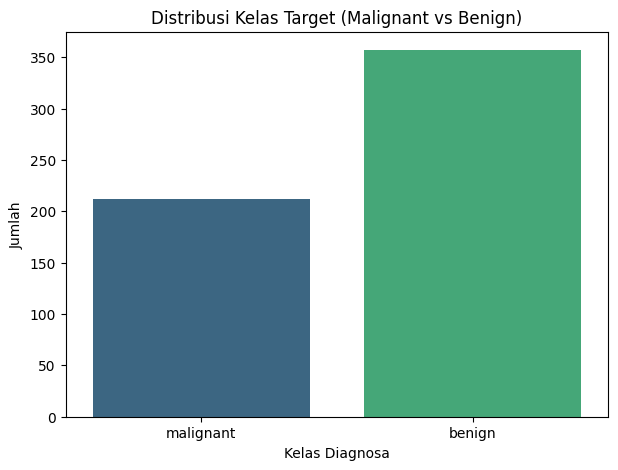

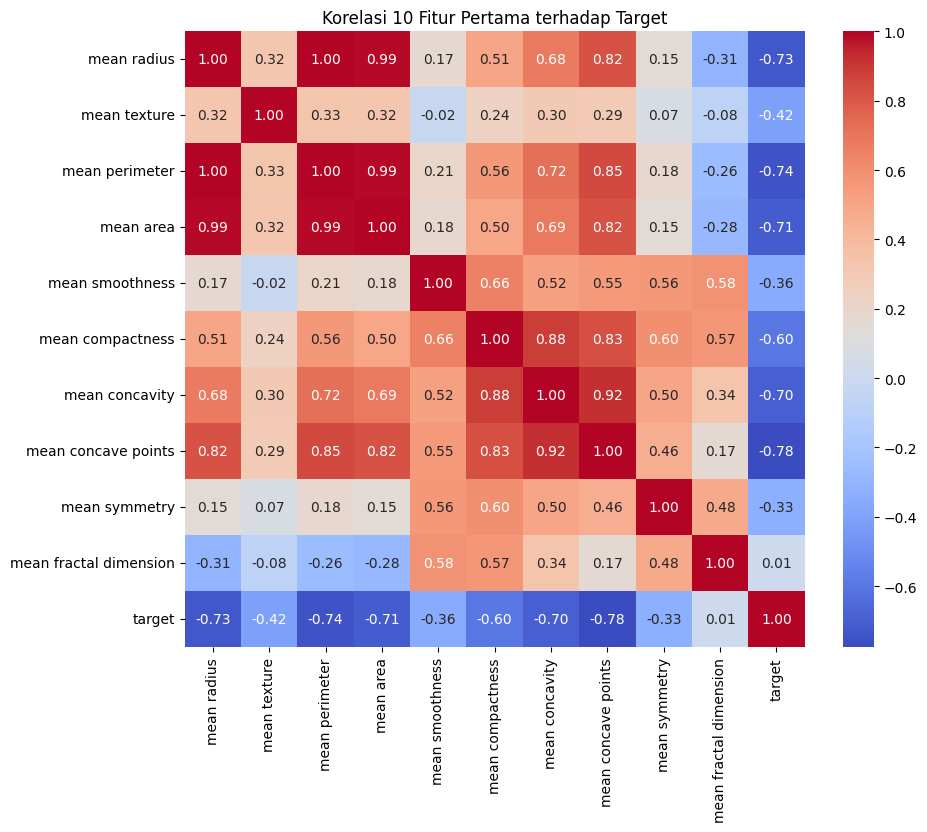

In [3]:
print("1. Informasi Struktur Dataset:")
df.info()

print("\n2. Pengecekan Missing Values:")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

print("\n3. Pengecekan Data Duplikat:")
print(f"Total Data Duplikat: {df.duplicated().sum()}")

# Visualisasi Distribusi Kelas Target
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='target_name', palette='viridis')
plt.title('Distribusi Kelas Target (Malignant vs Benign)')
plt.xlabel('Kelas Diagnosa')
plt.ylabel('Jumlah')
plt.show()

# Visualisasi Matriks Korelasi (Mengambil 10 fitur pertama + target untuk kejelasan)
plt.figure(figsize=(10, 8))
subset_cols = list(data.feature_names[:10]) + ['target']
sns.heatmap(df[subset_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi 10 Fitur Pertama terhadap Target')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Drop kolom yang tidak diperlukan untuk pemodelan (label teks)
X = df.drop(columns=['target', 'target_name'])
y = df['target']

# 2. Standarisasi Fitur Menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 3. Membagi data menjadi Training dan Testing (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensi Dataset Setelah Split:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Evaluasi Preprocessing: Memastikan Mean mendekati 0 dan Std Dev mendekati 1
print("Evaluasi Preprocessing (Standardization):")
print(f"Rata-rata fitur (X_train):\n{X_train.mean().head(3)}\n")
print(f"Standar Deviasi fitur (X_train):\n{X_train.std().head(3)}\n")

# 4. Menyimpan dataset yang sudah diproses ke folder (Sebagai persiapan untuk automate.py)
os.makedirs('dataset', exist_ok=True)
X_train.to_csv('dataset/X_train.csv', index=False)
X_test.to_csv('dataset/X_test.csv', index=False)
y_train.to_csv('dataset/y_train.csv', index=False)
y_test.to_csv('dataset/y_test.csv', index=False)

print("Dataset berhasil diproses dan disimpan di folder 'dataset/'!")

Dimensi Dataset Setelah Split:
X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)

Evaluasi Preprocessing (Standardization):
Rata-rata fitur (X_train):
mean radius      -0.017063
mean texture     -0.009840
mean perimeter   -0.016955
dtype: float64

Standar Deviasi fitur (X_train):
mean radius       0.993874
mean texture      1.025141
mean perimeter    0.994712
dtype: float64

Dataset berhasil diproses dan disimpan di folder 'dataset/'!
